In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'


from AI4AO import PyramidWFS, DeformableMirror

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

In [2]:
imat_data = np.load(r"../Data/Rama/Rama_imats2.npz")
iMat_modal = imat_data["iMat_modal"]
iMat_zonal = imat_data["iMat_zonal"]
pyrMap = imat_data["pupils"]

M2C = np.load(r"../Data/Rama/M2C.npy")
# M2C = np.eye(iMat_zonal.shape[0])
M2C = torch.from_numpy(M2C).to(device = device, dtype = torch.float32)


# _COORDS = ((24, 30), (529, 32), (530, 524), (31, 530))
_COORDS = ((27, 31), (529, 31), (529, 527), (27, 527))
pupil_size = 36
pupil_separation = 6
pyrImSizeX = 560
pyrImSizeY = 560

temp_crop = np.zeros((4, pupil_size + pupil_separation * 2, pupil_size + pupil_separation * 2))
temp_full = test = np.zeros((pyrImSizeX,pyrImSizeY))

iMatCrop = np.zeros((iMat_modal.shape[0], 2*pupil_size + pupil_separation * 4, 2 * pupil_size + pupil_separation * 4))

for i in range(iMat_modal.shape[0]):
    temp_full[pyrMap != 0] = iMat_modal[i]
    for j, (x,y) in enumerate(_COORDS):
        temp_crop[j] = temp_full[x - pupil_separation - pupil_size//2:x + pupil_size//2 + pupil_separation, y - pupil_separation - pupil_size//2:y + pupil_size//2 + pupil_separation]
    tiled = np.block([
        [temp_crop[0], temp_crop[3]],
        [temp_crop[1], temp_crop[2]]
    ])
    iMatCrop[i] = tiled

iMat_bench = torch.from_numpy(iMatCrop).to(device=device, dtype = torch.float32)

reference_frame = iMat_bench.std(dim = 0)
reference_frame = (reference_frame > reference_frame.max() * 0.02).to(device=device, dtype = torch.float32)
reference_frame /= reference_frame.sum()

In [3]:
WFSParams = {"Nres":36,
             "sampling":96/36,
             "D": 0.6,
             "useNoise": False,
             "Modulation": 3,
             "MaskType": "Pyramid",
             "beamSplitProportionForWFSDetector": 0,
             "Nactuator": 11,
             "Wavelength": 635e-9
             }

wfs = PyramidWFS(WFSParams, device)

c:\Users\foyarzun\AOvenv\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4217.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


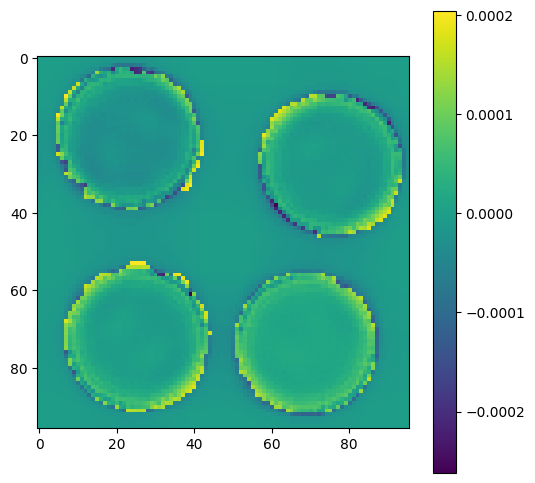

In [4]:
"""
Trains the MaskGenerator neural network to match a target mask pattern.
Generates live plots and saves intermediate mask states into a GIF.

Args:
    maskGenerator (nn.Module): Neural network to generate the mask.
    uv_coords (Tensor): 2D coordinates input to the mask generator.
    mask (Tensor): Target mask used for loss computation.
    loss (function): Loss function to optimize.
    TrainRunNb (int): Number of training iterations.
    optimizer (torch.optim.Optimizer): Optimizer used for training.
    device (str): Device for computation.

Returns:
    None
"""
final_train_loss = 0

TrainRunNb = 200
loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))


img = ax.imshow(reference_frame.cpu().detach().numpy())
fig.colorbar(img)
plt.show()

optimizer = torch.optim.AdamW(wfs.parameters(), 2e-3, fused = True)
wfs.train()

for u in range(0,TrainRunNb) :
    

    optimizer.zero_grad()
    
    wfs.BuildMask()

    wfs.BuildReferenceIntensity() 

    digital_image = wfs.reference_intensity * 1e5
    

    l = loss(reference_frame * 1e5,digital_image)

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((reference_frame - wfs.reference_intensity).cpu().detach().numpy())
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.1)
    



In [5]:
DMParams = {"moffatParam":2,
            "signedAmplitude": 2e-6,
            "MechCoupling": 0.36, 
            "FlipLeftRight": True,
            "FlipTopBottom": False}

param = {}
param['rotationAngle'] = 45
# shift X in m
param['shiftX'] = 0
# shift Y in m
param['shiftY'] = 0
# amamorphosis angle in degrees
param['anamorphosisAngle'] = 0
# normal scaling in % of diameter
param['tangentialScaling'] = 0
# radial scaling in % of diameter
param['radialScaling'] = 0

dm = DeformableMirror(WFSParams,
                    DMParams,
                    device=device,
                    offset_to_fit_number_of_actuators=0.1,
                    misreg=param)


wfs.BuildReferenceIntensity()
dm.RoughCalibration(wfs, iMat_bench, M2C)

Best configuration found to be: 
Rotation angle: 45.0
Sign: Possitive
Flip left-right: True
Flip top-bottom: False

Updating values in the DM


In [6]:
ref_phase = torch.nn.Parameter(torch.zeros(*wfs.pupil.shape, device = device, dtype = torch.float32))
ref_pupil = torch.nn.Parameter(torch.ones(*wfs.pupil.shape, device = device, dtype = torch.float32))

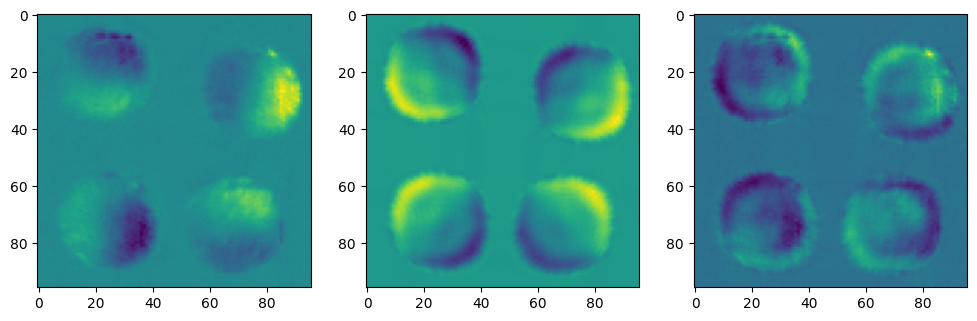

In [8]:
index = list(range(0,96,1))
target = iMat_bench[index]

dm.modesComputation()
modes = dm.GetModalModes(M2C[:,index])
amp = 1e-2

wfs.BuildInteractionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)
digital_image = wfs.iMat

idx = 3
plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(target[idx].cpu().numpy())

plt.subplot(132)
plt.imshow(digital_image[idx].cpu().detach().numpy())

plt.subplot(133)
plt.imshow((target - digital_image)[idx].cpu().detach().numpy())

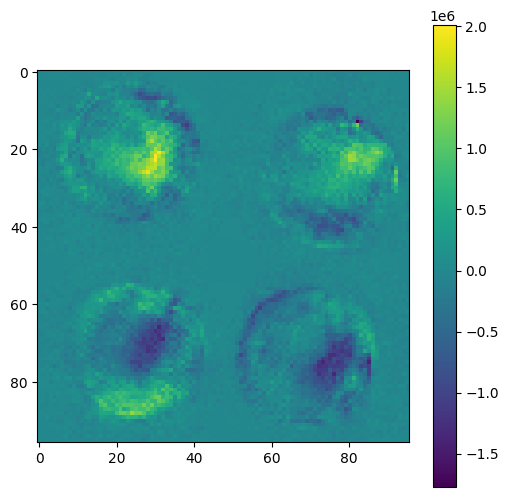

########################################
loss = 0.00769
########################################
({'rotationAngle': 64.1874771118164, 'shiftX': -0.01476099987824758, 'shiftY': -0.0005093792453408241, 'anamorphosisAngle': -69.81958770751953, 'tangentialScaling': 6.301415711641312, 'radialScaling': 7.52454474568367}, {'moffatParam': 0.9633222818374634, 'signedAmplitude': 1.2378178553262842e-06, 'MechCoupling': 0.5239530801773071, 'FlipLeftRight': True, 'FlipTopBottom': False})


In [9]:
TrainRunNb = 200

loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))

img = ax.imshow(target[4].cpu().detach().numpy())
fig.colorbar(img)

original_positons = dm.anamorphosis_coordinates(dm.actuator_positions)
original_positons = dm.rotate_coordinates(original_positons)


warmup_iters = TrainRunNb // 2
lr_start = -10
lr_end = -2

optimizer = torch.optim.AdamW(  [{"params": dm.parameters(), "lr": 1e-2},
                                {"params": [ref_phase, ref_pupil], "lr": 10**lr_start}],
                                fused=True
                                )


wfs.reference_intensity = None

for u in range(0,TrainRunNb) :

    if u < warmup_iters:
        alpha = u / warmup_iters
        optimizer.param_groups[1]["lr"] = 10**(
            lr_start + alpha * (lr_end - lr_start)
        )
    if u == warmup_iters:
        optimizer.param_groups[1]["lr"] = 10**lr_end
    
    optimizer.zero_grad()
    with torch.no_grad():
        wfs.BuildMask()
    
    modes = dm(M2C[:,index])

    wfs.BuildInteractionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

    digital_image = wfs.iMat
    
    l = ((target - digital_image)**2).sum()

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((target - digital_image)[4].cpu().detach().numpy()*1e10)
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.5)

        print("#"*40)
        print(f'loss = {l.item():.5f}')
        print("#"*40)
    
print(dm.GetMisreg())

transformed_positons = dm.anamorphosis_coordinates(dm.actuator_positions)
transformed_positons = dm.rotate_coordinates(transformed_positons)

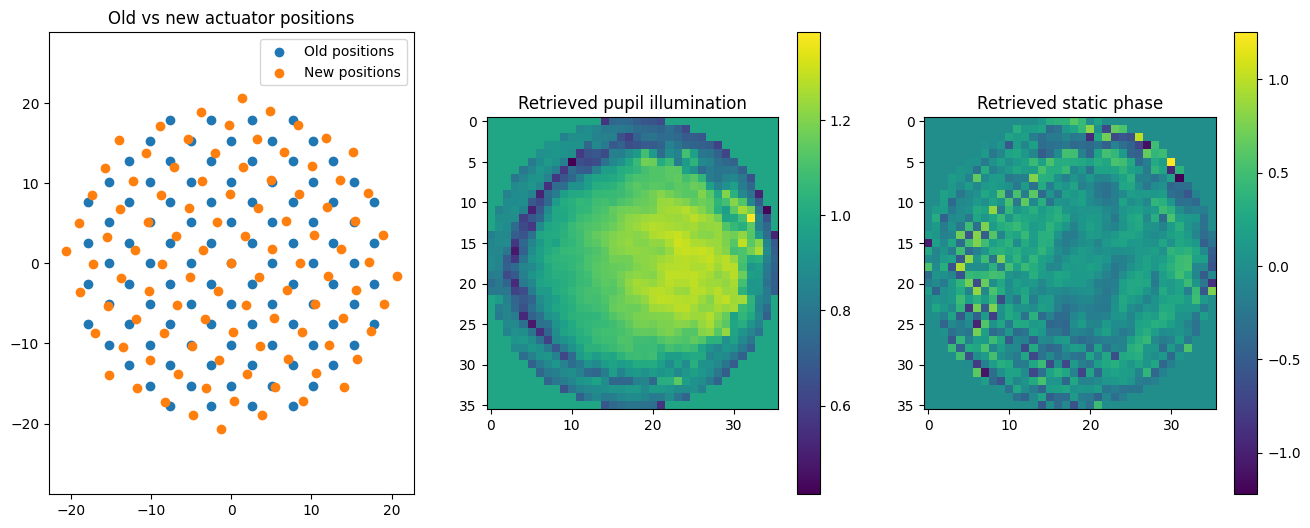

In [10]:
plt.figure(figsize=(16,6))
plt.subplot(131)
plt.title("Old vs new actuator positions")
plt.scatter(original_positons[:,0].cpu().detach(), original_positons[:,1].cpu().detach())
plt.scatter(transformed_positons[:,0].cpu().detach(), transformed_positons[:,1].cpu().detach())
plt.legend(['Old positions', 'New positions'])
plt.axis('equal')
plt.subplot(132)
plt.title('Retrieved pupil illumination')
plt.imshow(ref_pupil.cpu().detach())
plt.colorbar()
plt.subplot(133)
plt.title('Retrieved static phase')
plt.imshow(ref_phase.cpu().detach())
plt.colorbar()

In [11]:
dm.modesComputation()
modes = dm.GetModalModes(M2C)

with torch.no_grad():
    wfs.BuildReconstructionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

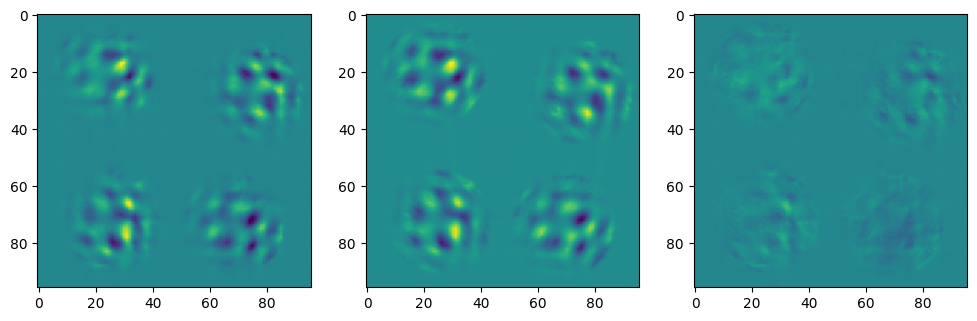

In [12]:
idx = 57
plt.figure(figsize = (12,4))
plt.subplot(131)
plt.imshow((iMat_bench)[idx].cpu().detach().numpy())
plt.subplot(132)
plt.imshow((wfs.iMat)[idx].view_as(reference_frame).cpu().detach().numpy())
plt.subplot(133)
plt.imshow((iMat_bench[idx] - (wfs.iMat)[idx].view_as(reference_frame)).cpu().detach().numpy(), vmin=(iMat_bench)[idx].cpu().detach().numpy().min(), vmax=(iMat_bench)[idx].cpu().detach().numpy().max())

In [13]:
with torch.no_grad():
    cov = iMat_bench.flatten(start_dim = -2) @ wfs.reconstructionMatrix

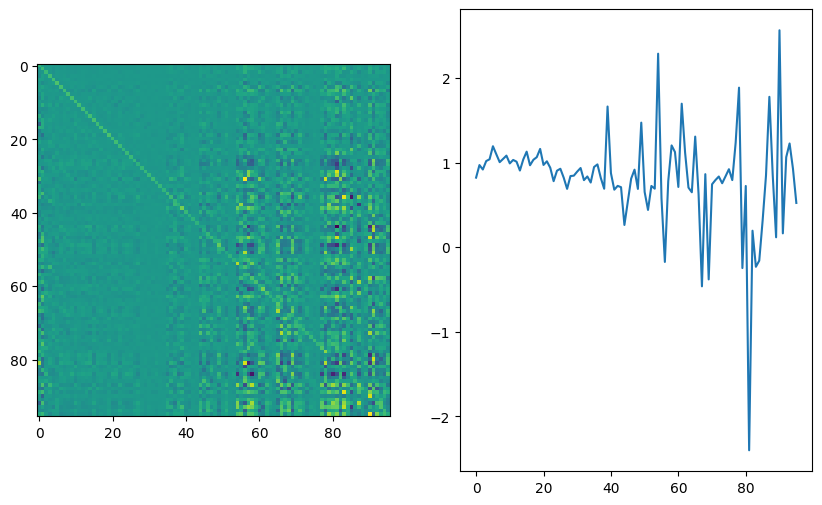

In [14]:
plt.figure(figsize=(10,6))
plt.subplot(121)
plt.imshow(cov.cpu().detach())
plt.subplot(122)
plt.plot(torch.diag(cov).cpu().detach())

In [15]:
misreg, dmdict = dm.GetMisreg()

print(misreg)

print(dmdict)

{'rotationAngle': 64.1874771118164, 'shiftX': -0.01476099987824758, 'shiftY': -0.0005093792453408241, 'anamorphosisAngle': -69.81958770751953, 'tangentialScaling': 6.301415711641312, 'radialScaling': 7.52454474568367}
{'moffatParam': 0.9633222818374634, 'signedAmplitude': 1.2378178553262842e-06, 'MechCoupling': 0.5239530801773071, 'FlipLeftRight': True, 'FlipTopBottom': False}


In [16]:
PATH_WFS = "../Data/Rama/RamaWFS.pth"
torch.save(wfs.state_dict(), PATH_WFS)

PATH_DM = "../Data/Rama/RamaDM.pth"
torch.save(dm.state_dict(), PATH_DM)

checkpoint = torch.load(PATH_WFS, weights_only=True)
wfs.load_state_dict(checkpoint)

checkpoint = torch.load(PATH_DM, weights_only=True)
dm.load_state_dict(checkpoint)

<All keys matched successfully>

In [17]:
dm.GetMisreg()

({'rotationAngle': 64.1874771118164,
  'shiftX': -0.01476099987824758,
  'shiftY': -0.0005093792453408241,
  'anamorphosisAngle': -69.81958770751953,
  'tangentialScaling': 6.301415711641312,
  'radialScaling': 7.52454474568367},
 {'moffatParam': 0.9633222818374634,
  'signedAmplitude': 1.2378178553262842e-06,
  'MechCoupling': 0.5239530801773071,
  'FlipLeftRight': True,
  'FlipTopBottom': False})